<a href="https://colab.research.google.com/github/Hyounseo/Opensource-FISH/blob/main/TF-IDF%20%EB%B0%8F%20MLP%20%EA%B8%B0%EB%B0%98%20%ED%85%8D%EC%8A%A4%ED%8A%B8%20%ED%94%BC%EC%8B%B1%20%ED%8C%90%EB%B3%84%20%EB%AA%A8%EB%8D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


🎯 현재 연산 디바이스: GPU (Cuda)
📊 순수 원본 데이터셋 로드 완료! (총 샘플 수: 147개)

🚀 순수 원본 데이터 기반 MLP 학습 시작 (120 Epochs)...
Epoch 1/120


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.7849 - loss: 0.6791 - val_accuracy: 0.9583 - val_loss: 0.6564
Epoch 2/120
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9032 - loss: 0.6496 - val_accuracy: 0.9583 - val_loss: 0.6295
Epoch 3/120
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9032 - loss: 0.6205 - val_accuracy: 0.9583 - val_loss: 0.5981
Epoch 4/120
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9032 - loss: 0.5854 - val_accuracy: 0.9583 - val_loss: 0.5598
Epoch 5/120
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9032 - loss: 0.5429 - val_accuracy: 0.9583 - val_loss: 0.5144
Epoch 6/120
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9032 - loss: 0.4929 - val_accuracy: 0.9583 - val_loss: 0.4629
Epoch 7/120
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9032 - loss: 0.4353 - val_accuracy: 0.9583 - val_loss: 0.4069
Epoch 8/120
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9032 - loss: 0.3765 - val_accuracy: 0.9583 - val_

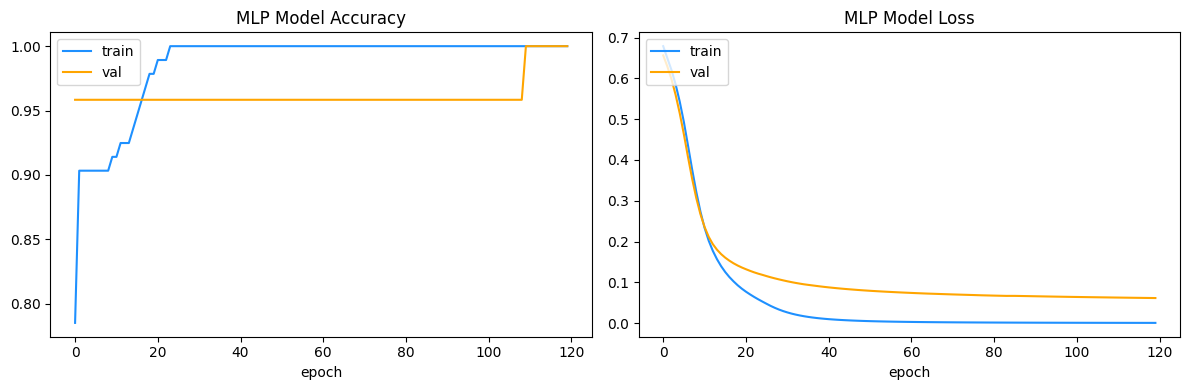

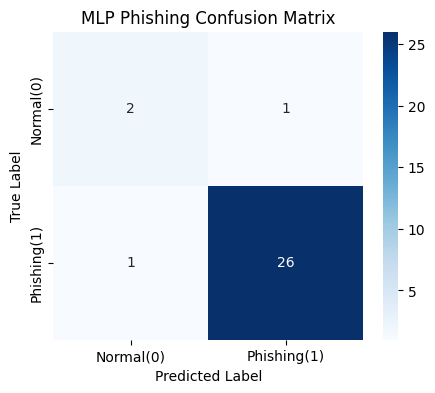

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f3418a61540068d41d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install -q easyocr pandas numpy matplotlib seaborn tensorflow gradio

import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import easyocr

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import gradio as gr

# 시드 고정
seed = 7
np.random.seed(seed)
tf.random.set_seed(seed)

print("🎯 현재 연산 디바이스: GPU (Cuda)")

# =====================================================================
# 2. 오직 원본 'phishing_dataset.csv' 파일만 다이렉트 로드
# =====================================================================
csv_path = '/content/phishing_dataset.csv'

if not os.path.exists(csv_path):
    raise FileNotFoundError("❌ 왼쪽 파일 창에 'phishing_dataset.csv' 파일이 없습니다! 마우스로 드래그해서 넣어주세요.")

# 임의의 텍스트 추가 없이 오직 원본 데이터만 사용
df = pd.read_csv(csv_path)
df['text'] = df['text'].fillna('')

print(f"📊 순수 원본 데이터셋 로드 완료! (총 샘플 수: {len(df)}개)")

# =====================================================================
# 3. 데이터 분리 및 TF-IDF 벡터화 파이프라인
# =====================================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# 학습 데이터의 단어들로만 정직하게 단어 사전 빌드
tfidf = TfidfVectorizer(max_features=500, min_df=1)
X_train = tfidf.fit_transform(X_train_raw).toarray()
X_test = tfidf.transform(X_test_raw).toarray()

# =====================================================================
# 4. Sequential MLP 모델 생성 및 가중치 학습
# =====================================================================
model = Sequential()
model.add(Dense(16, input_dim=500, kernel_initializer='glorot_uniform', activation='relu'))
model.add(Dense(8, kernel_initializer='glorot_uniform', activation='relu'))
model.add(Dense(1, kernel_initializer='glorot_uniform', activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\n🚀 순수 원본 데이터 기반 MLP 학습 시작 (120 Epochs)...")
history = model.fit(X_train, y_train, validation_split=0.2, epochs=120, batch_size=8, verbose=1)
print("🔔 모델 가중치 로컬 빌드 완료!")

# 검증 세트 평가
yhat_probability = model.predict(X_test)
yhat_classes = (yhat_probability > 0.5).astype(int).flatten()

print("\n=== 📝 MLP 상세 평가지표 ===")
print(classification_report(y_test, yhat_classes, target_names=['Normal(0)', 'Phishing(1)']))

# =====================================================================
# 5. 평가지표 학습 곡선 시각화
# =====================================================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train', color='dodgerblue')
plt.plot(history.history['val_accuracy'], label='val', color='orange')
plt.title('MLP Model Accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train', color='dodgerblue')
plt.plot(history.history['val_loss'], label='val', color='orange')
plt.title('MLP Model Loss')
plt.xlabel('epoch')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 혼동 행렬 출력
cm = confusion_matrix(y_test, yhat_classes)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal(0)', 'Phishing(1)'],
            yticklabels=['Normal(0)', 'Phishing(1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('MLP Phishing Confusion Matrix')
plt.show()

# =====================================================================
# 6. 실시간 시연용 Gradio 웹 UI 연동 모듈 (📸 원본 이미지 인풋 방식)
# =====================================================================
reader = easyocr.Reader(['ko', 'en'], gpu=True)

def web_predict_phishing_mlp(image):
    if image is None:
        return "⚠️ 시연할 웹사이트 스크린샷 이미지를 업로드해 주세요."

    # 사용자가 업로드한 이미지에서 실시간 글자 추출
    result = reader.readtext(image, detail=0)
    extracted_text = " ".join(result)

    if not extracted_text.strip():
        return "🍏 [안전] 이미지에서 추출된 텍스트가 없어 안전한 페이지로 판단됩니다."

    # 추출된 텍스트를 학습된 TF-IDF로 변환 후 로컬 MLP 모델로 추론
    vectorized_text = tfidf.transform([extracted_text]).toarray()
    phishing_prob = float(model.predict(vectorized_text, verbose=0)[0][0])
    pred_class = int(phishing_prob > 0.5)

    # 분석 결과 리포트 출력
    report =  f"🔎 [이미지 실시간 스캔 문장]:\n\"{extracted_text}\"\n\n"
    report += f"📊 #-- 피싱 위험 확률 --# : {phishing_prob*100:.2f}%\n"
    report += f"📊 #-- 최종 판별 클래스 --# : {pred_class} (0:정상, 1:피싱)\n"
    report += "="*45 + "\n"

    if pred_class == 1:
        report += f"🚨 [경고] 피싱 위험도가 매우 높습니다! 해당 웹사이트 접속을 차단합니다."
    else:
        report += f"🍏 [안전] 피싱 위험 요소가 없는 깨끗한 정상 사이트입니다."

    return report

# 그라디오 UI 세팅 (📸 이미지 파일 드롭다운 창)
demo = gr.Interface(
    fn=web_predict_phishing_mlp,
    inputs=gr.Image(type="filepath", label="📸 웹사이트 캡처 이미지 업로드"),
    outputs=gr.Textbox(label="🚨 실시간 로컬 MLP 인공지능 분석 리포트", lines=10),
    title="🛡️ TF-IDF + MLP 기반 실시간 웹 피싱 차단 시스템",
    description="웹사이트 스크린샷 이미지를 마우스로 드래그하여 올리면, 내부 EasyOCR 엔진과 순수 원본 데이터로 학습된 로컬 MLP 신경망 연산을 거쳐 실시간 피싱 유무를 판별합니다.",
    theme="soft"
)


In [10]:

demo.launch(
    share=True,          # 외부에서 접속 가능한 퍼블릭 링크 생성
    inline=False,         # 코랩 내부 출력이 안 잘리도록 아예 새 탭으로 열기 설정
    debug=True           # 혹시 모를 에러 로그 트래킹 활성화
)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c48283d67c08fdb0d3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c48283d67c08fdb0d3.gradio.live
